# Projet Machine Learning – 4MA 2025-2026
## Prédiction du risque cardiovasculaire et du cholestérol LDL
### Notebook R

**Jeu de données :** *Cardiovascular Disease Risk Prediction Dataset* (15 000 patients synthétiques)

Ce notebook couvre en R :
1. **Analyse exploratoire** (univariée, bivariée, ACP)
2. **Prédiction de `Heart_Disease_Risk`** (classification)
3. **Prédiction de `Cholesterol_LDL`** (régression)

## 0. Chargement des packages

In [1]:
# Installation si nécessaire (décommenter si besoin)
# install.packages(c("tidyverse","caret","randomForest","gbm","e1071",
#                    "rpart","rpart.plot","nnet","glmnet","FactoMineR",
#                    "factoextra","pROC","corrplot","gridExtra","MLmetrics"))

library(tidyverse)
library(caret)
library(randomForest)
library(gbm)
library(e1071)
library(rpart)
library(rpart.plot)
library(nnet)
library(glmnet)
library(FactoMineR)
library(factoextra)
library(pROC)
library(corrplot)
library(gridExtra)

set.seed(42)
cat("Packages chargés avec succès\n")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Le chargement a nécessité le package : lattice


Attachement du package : ‘caret’


L'objet suivant est masqué depuis ‘package:purrr’:

    lift


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attachement du package : ‘randomForest’


L'objet suivant est masqué depuis ‘package:dplyr’:

    combine


L'objet suivant est masqué depuis ‘package:ggplot2’:

    margin


Loaded gbm 2.2.2

This version of gbm is no longer under development. Conside

Packages chargés avec succès


## 1. Chargement et vérification des données
### Question 1 – Nature des variables et encodage

In [2]:
# Chargement du fichier CSV
df <- read.csv("healthcare_synthetic_data.csv", stringsAsFactors = FALSE)
cat("Dimensions :", nrow(df), "lignes x", ncol(df), "colonnes\n")
head(df)

Dimensions : 15000 lignes x 19 colonnes


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
2,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
3,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
4,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
5,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
6,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0


In [3]:
# Types des variables
str(df)

'data.frame':	15000 obs. of  19 variables:
 $ Patient_ID             : chr  "PID-00001" "PID-00002" "PID-00003" "PID-00004" ...
 $ Age                    : int  60 53 62 73 52 52 73 64 49 61 ...
 $ Gender                 : int  0 0 1 1 1 0 0 0 0 1 ...
 $ Height_cm              : num  147 162 175 173 179 ...
 $ Weight_kg              : num  51.3 76.6 92.4 68.9 79.8 ...
 $ BMI                    : num  23.8 29.3 30.3 22.9 25 23.7 25 34.5 28.2 36.3 ...
 $ Systolic_BP            : int  140 128 141 136 122 134 149 129 139 131 ...
 $ Diastolic_BP           : int  89 81 100 96 80 92 98 90 91 91 ...
 $ Cholesterol_Total      : int  217 203 173 193 236 225 260 237 227 206 ...
 $ Cholesterol_LDL        : int  151 119 124 117 153 155 166 160 138 139 ...
 $ Cholesterol_HDL        : int  52 38 45 45 41 48 46 44 37 38 ...
 $ Fasting_Blood_Sugar    : int  83 116 90 81 79 103 103 108 90 103 ...
 $ Smoking_Status         : int  0 0 0 0 0 0 0 0 1 0 ...
 $ Alcohol_Consumption    : int  1 0 0 0 1 0 0 1 0 

In [4]:
# Valeurs manquantes
cat("=== Valeurs manquantes par variable ===\n")
colSums(is.na(df))

=== Valeurs manquantes par variable ===


Patient_ID                     Age                  Gender 
                      0                       0                       0 
              Height_cm               Weight_kg                     BMI 
                      0                       0                       0 
            Systolic_BP            Diastolic_BP       Cholesterol_Total 
                      0                       0                       0 
        Cholesterol_LDL         Cholesterol_HDL     Fasting_Blood_Sugar 
                      0                       0                       0 
         Smoking_Status     Alcohol_Consumption Physical_Activity_Level 
                      0                       0                       0 
         Family_History            Stress_Level             Sleep_Hours 
                      0                       0                       0 
     Heart_Disease_Risk 
                      0

In [5]:
# Suppression de l'identifiant non informatif
df <- df %>% select(-Patient_ID)

# Variables qualitatives → facteurs
qual_vars <- c("Gender","Smoking_Status","Alcohol_Consumption",
               "Physical_Activity_Level","Family_History","Heart_Disease_Risk")

for (v in qual_vars) {
  df[[v]] <- as.factor(df[[v]])
}

# Vérification
str(df)

'data.frame':	15000 obs. of  18 variables:
 $ Age                    : int  60 53 62 73 52 52 73 64 49 61 ...
 $ Gender                 : Factor w/ 2 levels "0","1": 1 1 2 2 2 1 1 1 1 2 ...
 $ Height_cm              : num  147 162 175 173 179 ...
 $ Weight_kg              : num  51.3 76.6 92.4 68.9 79.8 ...
 $ BMI                    : num  23.8 29.3 30.3 22.9 25 23.7 25 34.5 28.2 36.3 ...
 $ Systolic_BP            : int  140 128 141 136 122 134 149 129 139 131 ...
 $ Diastolic_BP           : int  89 81 100 96 80 92 98 90 91 91 ...
 $ Cholesterol_Total      : int  217 203 173 193 236 225 260 237 227 206 ...
 $ Cholesterol_LDL        : int  151 119 124 117 153 155 166 160 138 139 ...
 $ Cholesterol_HDL        : int  52 38 45 45 41 48 46 44 37 38 ...
 $ Fasting_Blood_Sugar    : int  83 116 90 81 79 103 103 108 90 103 ...
 $ Smoking_Status         : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 1 2 1 ...
 $ Alcohol_Consumption    : Factor w/ 3 levels "0","1","2": 2 1 1 1 2 1 1 2 1 1 ...
 $ Phy

In [6]:
# Résumé statistique global
summary(df)

      Age        Gender     Height_cm       Weight_kg           BMI       
 Min.   :25.00   0:7622   Min.   :138.5   Min.   : 33.70   Min.   :14.50  
 1st Qu.:46.00   1:7378   1st Qu.:158.5   1st Qu.: 65.20   1st Qu.:24.50  
 Median :55.00            Median :164.7   Median : 73.90   Median :27.20  
 Mean   :54.54            Mean   :165.3   Mean   : 75.25   Mean   :27.45  
 3rd Qu.:63.00            3rd Qu.:172.0   3rd Qu.: 83.90   3rd Qu.:30.00  
 Max.   :85.00            Max.   :198.1   Max.   :150.10   Max.   :46.10  
  Systolic_BP     Diastolic_BP    Cholesterol_Total Cholesterol_LDL
 Min.   : 90.0   Min.   : 60.00   Min.   :127.0     Min.   : 70.0  
 1st Qu.:127.0   1st Qu.: 85.00   1st Qu.:201.0     1st Qu.:128.0  
 Median :135.0   Median : 91.00   Median :216.0     Median :140.0  
 Mean   :135.1   Mean   : 90.54   Mean   :216.2     Mean   :140.4  
 3rd Qu.:143.0   3rd Qu.: 96.00   3rd Qu.:231.0     3rd Qu.:152.0  
 Max.   :182.0   Max.   :120.00   Max.   :303.0     Max.   :210.0  

## 2. Analyse descriptive univariée
### Question 2 – Statistiques et transformations

In [7]:
# Variables quantitatives
quant_vars <- c("Age","Height_cm","Weight_kg","BMI","Systolic_BP","Diastolic_BP",
                "Cholesterol_Total","Cholesterol_LDL","Cholesterol_HDL",
                "Fasting_Blood_Sugar","Stress_Level","Sleep_Hours")

# Statistiques descriptives
df_quant <- df[, quant_vars]
t(apply(df_quant, 2, function(x) c(
  Min=min(x), Q1=quantile(x,0.25), Mediane=median(x),
  Moyenne=mean(x), Q3=quantile(x,0.75), Max=max(x), Ecart_type=sd(x)
))) %>% round(2)

,Min,Q1.25%,Mediane,Moyenne,Q3.75%,Max,Ecart_type
Age,25.0,46.0,55.0,54.54,63.0,85.0,11.88
Height_cm,138.5,158.5,164.7,165.34,172.0,198.1,9.19
Weight_kg,33.7,65.2,73.9,75.25,83.9,150.1,14.11
BMI,14.5,24.5,27.2,27.45,30.0,46.1,4.13
Systolic_BP,90.0,127.0,135.0,135.12,143.0,182.0,11.26
Diastolic_BP,60.0,85.0,91.0,90.54,96.0,120.0,8.44
Cholesterol_Total,127.0,201.0,216.0,216.25,231.0,303.0,22.69
Cholesterol_LDL,70.0,128.0,140.0,140.36,152.0,210.0,17.91
Cholesterol_HDL,20.0,39.0,43.0,43.31,47.0,68.0,5.96
Fasting_Blood_Sugar,60.0,89.0,99.0,99.67,110.0,167.0,15.26


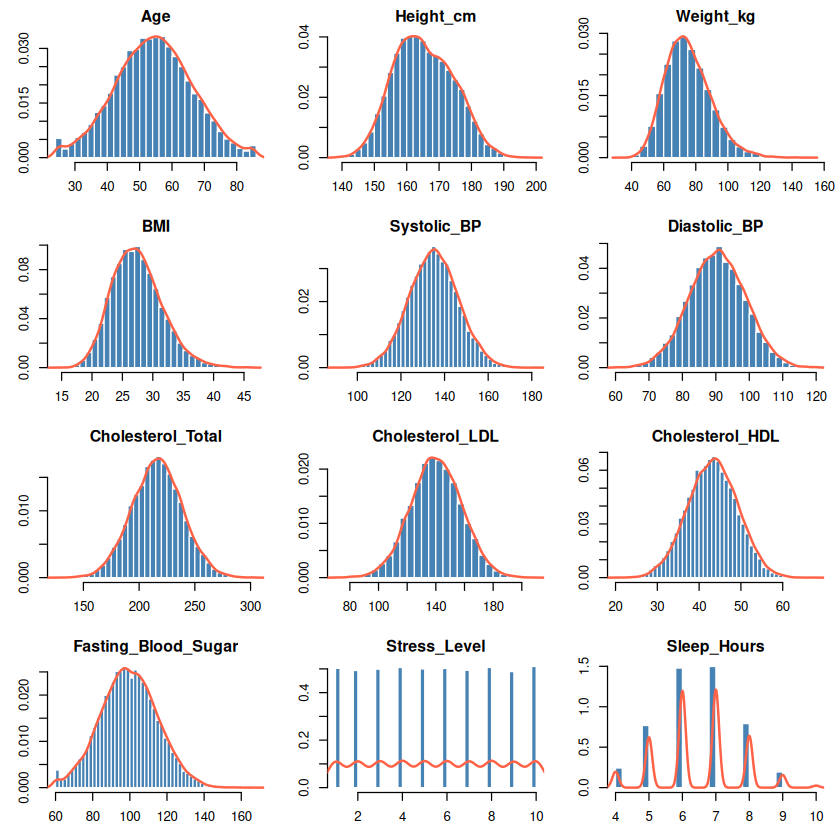

In [14]:
# Histogrammes des variables quantitatives
par(mfrow=c(4,3), mar=c(3,3,2,1))
for (v in quant_vars) {
  hist(df[[v]], main=v, xlab="", col="steelblue", border="white",
       breaks=40, probability=TRUE)
  lines(density(df[[v]]), col="tomato", lwd=2)
}

#enlever Stress and sleep

In [9]:
# Test de normalité (Shapiro-Wilk, sous-échantillon n=500)
cat("=== Tests de Shapiro-Wilk (H0 : normalité) ===\n")
set.seed(42)
idx <- sample(nrow(df), 500)
for (v in quant_vars) {
  sw <- shapiro.test(df[[v]][idx])
  cat(sprintf("  %-30s W=%.3f, p=%.4f  → %s\n",
              v, sw$statistic, sw$p.value,
              ifelse(sw$p.value > 0.05, "Normale", "Non normale")))
}

=== Tests de Shapiro-Wilk (H0 : normalité) ===
  Age                            W=0.995, p=0.1275  → Normale
  Height_cm                      W=0.991, p=0.0050  → Non normale
  Weight_kg                      W=0.969, p=0.0000  → Non normale
  BMI                            W=0.981, p=0.0000  → Non normale
  Systolic_BP                    W=0.996, p=0.2882  → Normale
  Diastolic_BP                   W=0.996, p=0.2433  → Normale
  Cholesterol_Total              W=0.997, p=0.5772  → Normale
  Cholesterol_LDL                W=0.994, p=0.0389  → Non normale
  Cholesterol_HDL                W=0.995, p=0.1528  → Normale
  Fasting_Blood_Sugar            W=0.996, p=0.2451  → Normale
  Stress_Level                   W=0.934, p=0.0000  → Non normale
  Sleep_Hours                    W=0.936, p=0.0000  → Non normale


In [10]:
# Skewness et kurtosis
library(e1071)
sk <- sapply(df_quant, skewness)
kt <- sapply(df_quant, kurtosis)
data.frame(Skewness=round(sk,3), Kurtosis=round(kt,3))

,Skewness,Kurtosis
,<dbl>,<dbl>
Age,0.011,-0.226
Height_cm,0.165,-0.456
Weight_kg,0.565,0.498
BMI,0.466,0.362
Systolic_BP,0.005,-0.028
Diastolic_BP,-0.009,-0.034
Cholesterol_Total,-0.005,0.025
Cholesterol_LDL,-0.014,0.059
Cholesterol_HDL,-0.020,-0.097


**Transformations :** La plupart des variables ne sont pas normales.
Pour la régression linéaire (LDL), nous vérifierons si une transformation log améliore les résidus.
Pour les modèles à base d'arbres, aucune transformation n'est nécessaire.

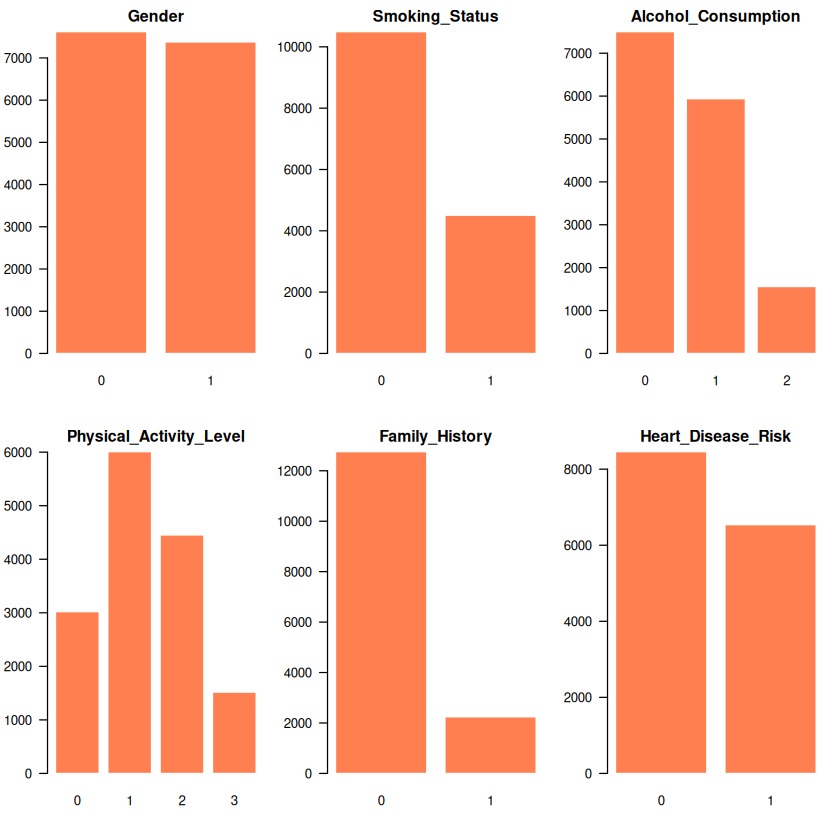

In [11]:
# Variables qualitatives – diagrammes en barres
par(mfrow=c(2,3), mar=c(4,3,2,1))
for (v in c("Gender","Smoking_Status","Alcohol_Consumption",
            "Physical_Activity_Level","Family_History","Heart_Disease_Risk")) {
  tbl <- table(df[[v]])
  barplot(tbl, main=v, col="coral", border="white",
          names.arg=names(tbl), las=1)
}

## 3. Analyse descriptive bivariée
### Question 3 – Visualisations et liaisons

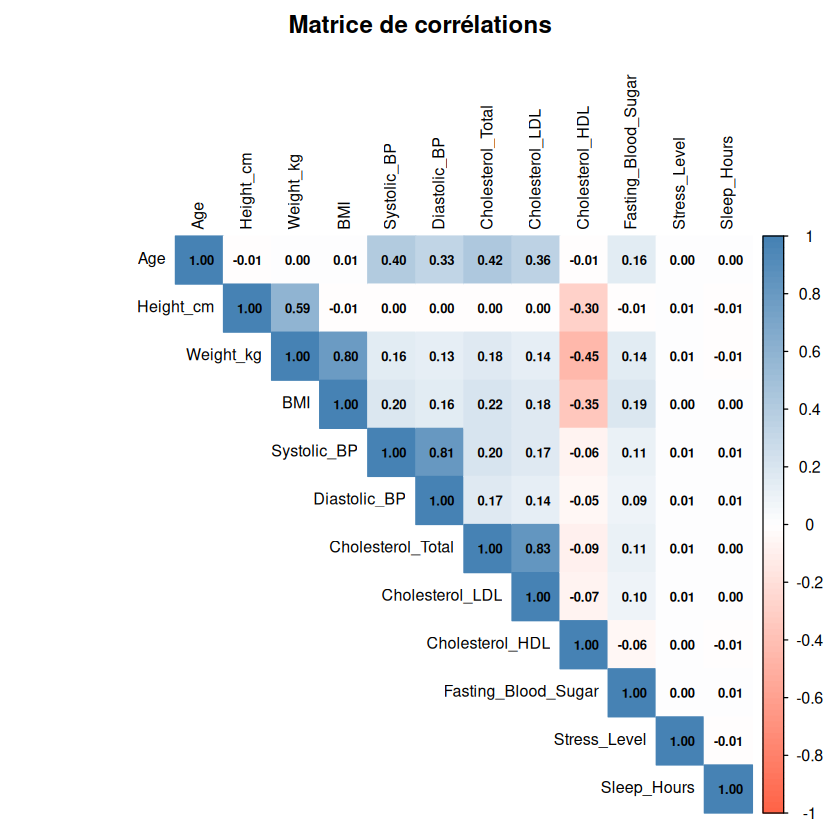

In [12]:
# Matrice de corrélations
corr_mat <- cor(df_quant)
corrplot(corr_mat, method="color", type="upper",
         addCoef.col="black", number.cex=0.65,
         tl.cex=0.8, tl.col="black",
         col=colorRampPalette(c("tomato","white","steelblue"))(100),
         title="Matrice de corrélations", mar=c(0,0,2,0))

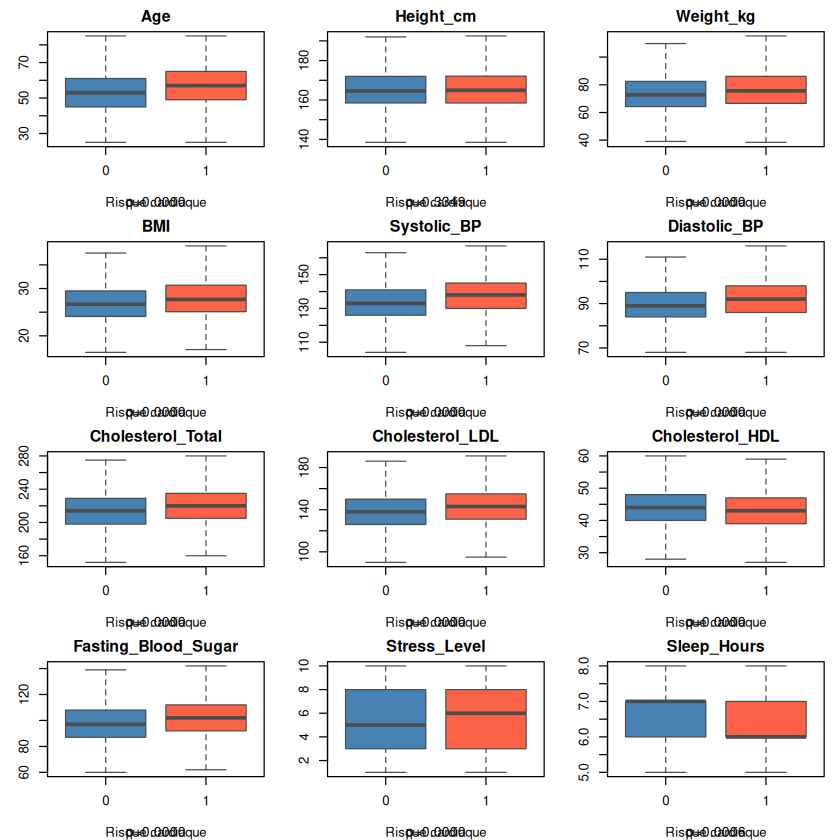

In [13]:
# Boxplots des variables quantitatives selon Heart_Disease_Risk
par(mfrow=c(4,3), mar=c(4,3,2,1))
for (v in quant_vars) {
  boxplot(df[[v]] ~ df$Heart_Disease_Risk,
          main=v, xlab="Risque cardiaque", ylab=v,
          col=c("steelblue","tomato"), border="gray30", outline=FALSE)
  # Test Mann-Whitney
  mw <- wilcox.test(df[[v]] ~ df$Heart_Disease_Risk)
  mtext(sprintf("p=%.4f", mw$p.value), side=1, line=3, cex=0.7)
}

In [15]:
# Tables de contingence et test du Chi2 : variables qualitatives vs risque
qual_expl <- c("Gender","Smoking_Status","Alcohol_Consumption",
               "Physical_Activity_Level","Family_History")
for (v in qual_expl) {
  ct <- table(df[[v]], df$Heart_Disease_Risk)
  chi2 <- chisq.test(ct)
  cat(sprintf("%-25s Chi2=%.2f, ddl=%d, p=%.4f\n",
              v, chi2$statistic, chi2$parameter, chi2$p.value))
}

Gender                    Chi2=0.01, ddl=1, p=0.9032
Smoking_Status            Chi2=1861.94, ddl=1, p=0.0000
Alcohol_Consumption       Chi2=1.34, ddl=2, p=0.5109
Physical_Activity_Level   Chi2=398.85, ddl=3, p=0.0000
Family_History            Chi2=606.88, ddl=1, p=0.0000


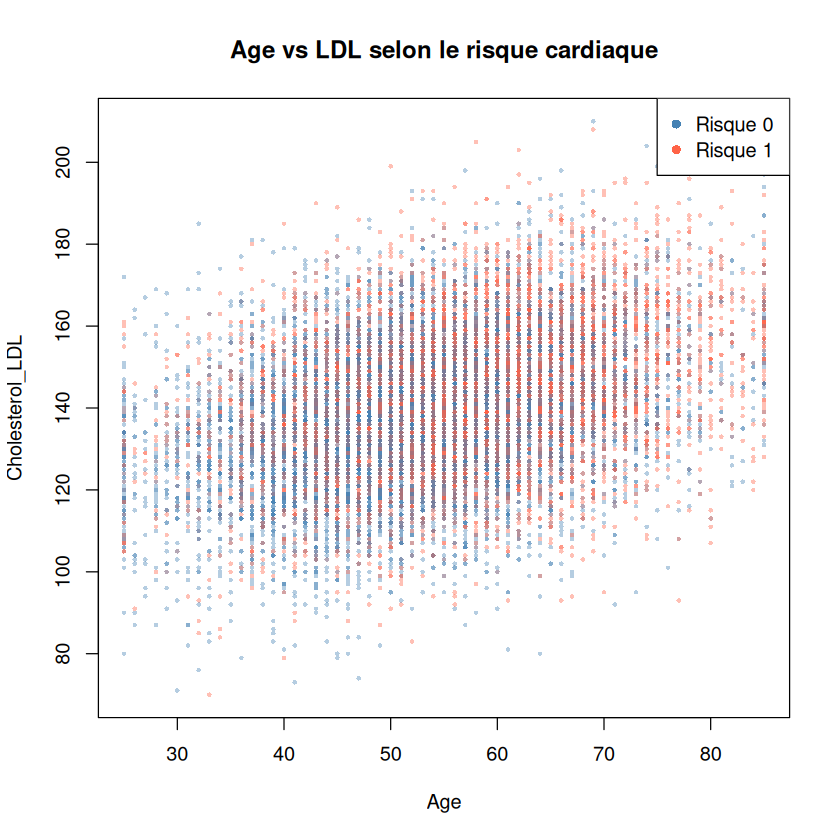

In [16]:
# Scatterplot Age vs Cholesterol_LDL, coloré par risque
plot(df$Age, df$Cholesterol_LDL,
     col=ifelse(df$Heart_Disease_Risk==1, adjustcolor("tomato",0.4),
                                          adjustcolor("steelblue",0.4)),
     pch=16, cex=0.5,
     xlab="Age", ylab="Cholesterol_LDL",
     main="Age vs LDL selon le risque cardiaque")
legend("topright", legend=c("Risque 0","Risque 1"),
       col=c("steelblue","tomato"), pch=16)

#Enlever

## 4. Analyse en Composantes Principales (ACP)
### Question 4

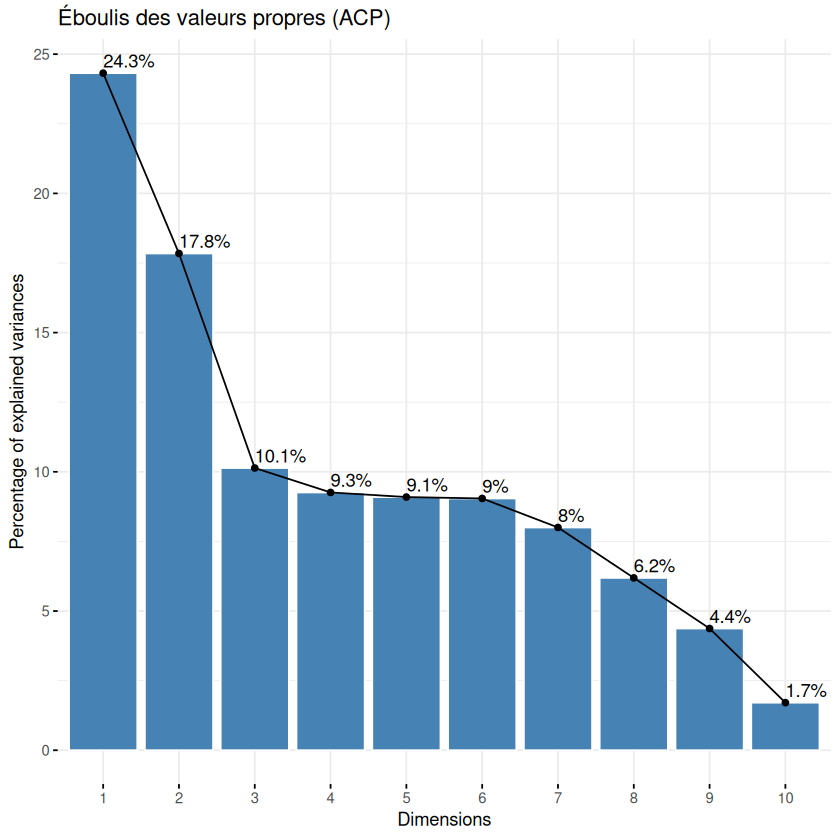

In [17]:
# ACP sur les variables quantitatives explicatives (hors Cholesterol_LDL)
quant_expl_pca <- quant_vars[quant_vars != "Cholesterol_LDL"]
df_pca <- df[, quant_expl_pca]

pca_res <- PCA(df_pca, scale.unit=TRUE, graph=FALSE)

# Éboulis des valeurs propres
fviz_eig(pca_res, addlabels=TRUE, barfill="steelblue", barcolor="white",
         main="Éboulis des valeurs propres (ACP)")

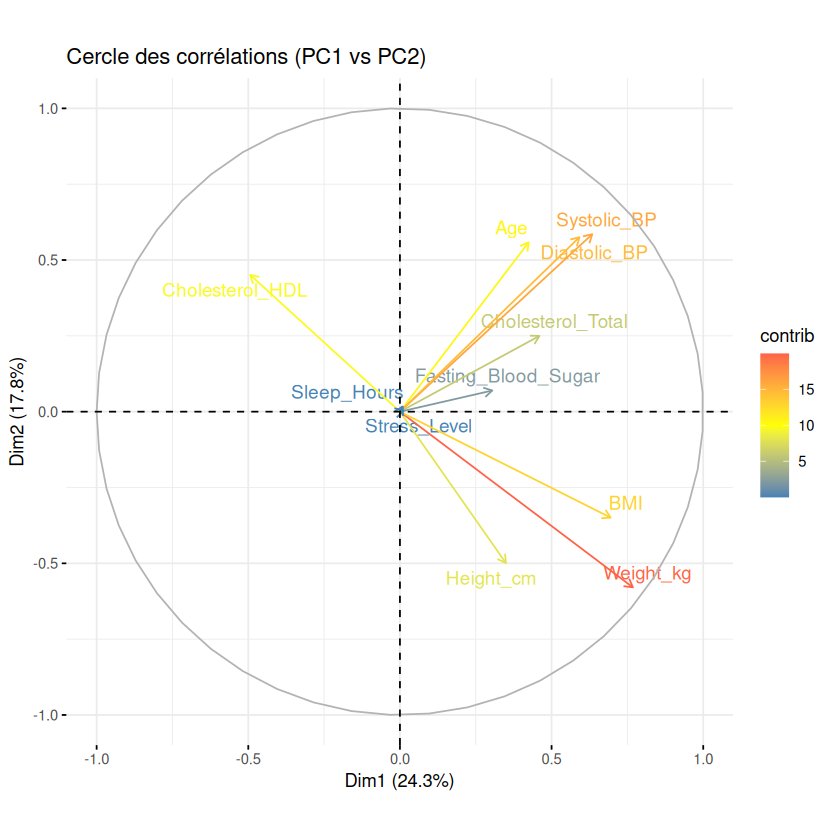

In [18]:
# Cercle des corrélations
fviz_pca_var(pca_res,
             col.var="contrib",
             gradient.cols=c("steelblue","yellow","tomato"),
             repel=TRUE,
             title="Cercle des corrélations (PC1 vs PC2)")

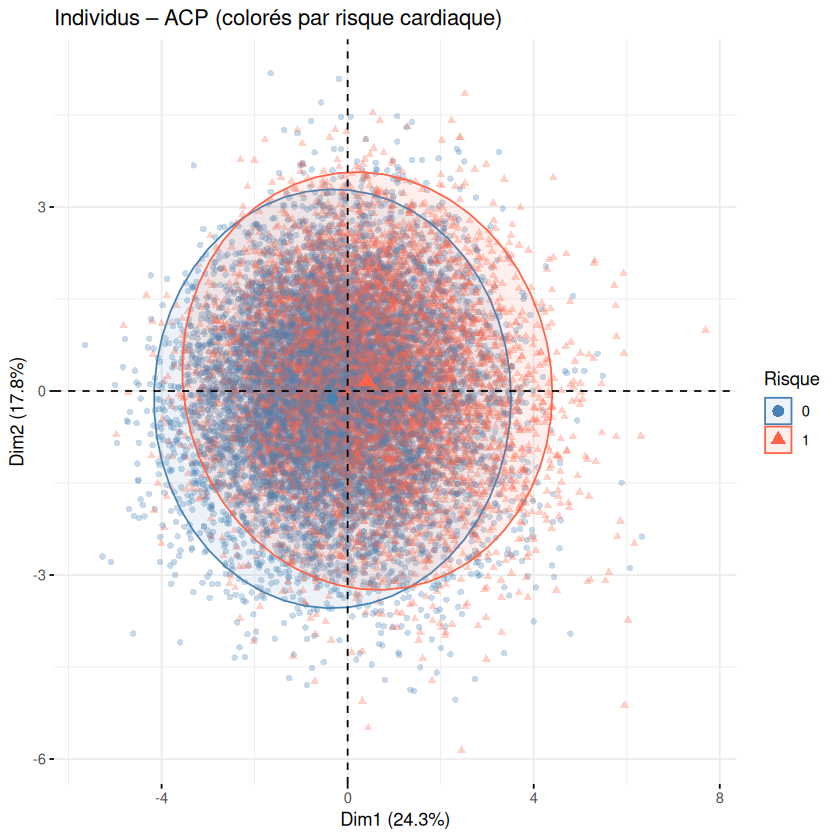

In [19]:
# Nuage des individus coloré par Heart_Disease_Risk
fviz_pca_ind(pca_res,
             col.ind=df$Heart_Disease_Risk,
             palette=c("steelblue","tomato"),
             alpha.ind=0.3,
             geom="point",
             addEllipses=TRUE, ellipse.level=0.95,
             legend.title="Risque",
             title="Individus – ACP (colorés par risque cardiaque)")

In [20]:
# Coordonnées des variables
pca_res$var$coord[, 1:4] %>% round(3)

,Dim.1,Dim.2,Dim.3,Dim.4
Age,0.424,0.558,0.197,0.389
Height_cm,0.349,-0.499,-0.426,0.422
Weight_kg,0.768,-0.579,-0.029,-0.024
BMI,0.695,-0.349,0.280,-0.344
Systolic_BP,0.634,0.585,-0.347,-0.156
Diastolic_BP,0.592,0.575,-0.404,-0.184
Cholesterol_Total,0.460,0.250,0.497,0.394
Cholesterol_HDL,-0.494,0.451,0.072,-0.052
Fasting_Blood_Sugar,0.305,0.070,0.526,-0.179
Stress_Level,0.012,0.003,-0.037,0.356


**Interprétation :**
- **PC1** oppose les variables lipidiques et la pression artérielle aux variables morphologiques.
- **PC2** capture la dimension morphologique (BMI, poids, taille).
- Les individus à risque élevé se situent davantage dans les zones de PC1 élevée.
- L'ellipse de confiance montre un chevauchement partiel entre les deux groupes, cohérent avec la difficulté de classification.

---
## 5. Prédiction de `Heart_Disease_Risk` (Classification)
### Question 1 – Découpage Train/Test

In [ ]:
# Préparation : encodage numérique pour caret
df_model <- df
for (v in c("Gender","Smoking_Status","Alcohol_Consumption",
            "Physical_Activity_Level","Family_History")) {
  df_model[[v]] <- as.numeric(df_model[[v]])
}
df_model$Heart_Disease_Risk <- factor(
  ifelse(df_model$Heart_Disease_Risk==1, "Risque1","Risque0"))

# Division 80/20 stratifiée
idx_train <- createDataPartition(df_model$Heart_Disease_Risk, p=0.8, list=FALSE)
train_c <- df_model[idx_train, ]
test_c  <- df_model[-idx_train, ]

cat("Train :", nrow(train_c), "observations\n")
cat("Test  :", nrow(test_c),  "observations\n")
prop.table(table(train_c$Heart_Disease_Risk))

**Pourquoi diviser en train/test ?** La division train/test permet d'évaluer la **capacité de généralisation** du modèle sur des données non vues.
Sans cette étape, on mesurerait la performance en entraînement (biais vers l'overfitting). L'option `stratify` préserve les proportions de chaque classe.

In [ ]:
# Contrôle de la validation croisée (5-fold, répété 1 fois)
ctrl <- trainControl(method="cv", number=5,
                     classProbs=TRUE, summaryFunction=twoClassSummary,
                     savePredictions="final")

cat("Contrôle CV configuré : 5-fold CV avec AUC comme métrique\n")

### Question 2 – Comparaison des modèles

#### A) Régression Logistique (avec et sans régularisation)

In [ ]:
# Régression Logistique classique
set.seed(42)
lr_fit <- train(Heart_Disease_Risk ~ ., data=train_c,
                method="glm", family="binomial",
                trControl=ctrl, metric="ROC",
                preProcess=c("center","scale"))
cat("RL classique – AUC CV :", max(lr_fit$results$ROC), "\n")

In [ ]:
# Régression Logistique avec pénalisation LASSO (alpha=1) via glmnet
# Hyperparamètre : lambda (force de régularisation)
glmnet_grid <- expand.grid(alpha=c(0, 0.5, 1),
                           lambda=10^seq(-4, 1, length=20))
set.seed(42)
glmnet_fit <- train(Heart_Disease_Risk ~ ., data=train_c,
                    method="glmnet",
                    trControl=ctrl, metric="ROC",
                    tuneGrid=glmnet_grid,
                    preProcess=c("center","scale"))
cat("glmnet – Meilleur alpha:", glmnet_fit$bestTune$alpha,
    "lambda:", round(glmnet_fit$bestTune$lambda,4),
    "AUC CV:", round(max(glmnet_fit$results$ROC),4), "\n")

#### B) SVM (noyau RBF)

In [ ]:
# SVM avec noyau radial (RBF)
# Hyperparamètres : C (coût de classification) et sigma (noyau RBF)
# Le noyau RBF est choisi car il capte les non-linéarités sans hypothèse de forme.
svm_grid <- expand.grid(C=c(0.1, 1, 10), sigma=c(0.01, 0.05, 0.1))
set.seed(42)
svm_fit <- train(Heart_Disease_Risk ~ ., data=train_c,
                 method="svmRadial",
                 trControl=ctrl, metric="ROC",
                 tuneGrid=svm_grid,
                 preProcess=c("center","scale"))
cat("SVM – Meilleur C:", svm_fit$bestTune$C,
    "sigma:", svm_fit$bestTune$sigma,
    "AUC CV:", round(max(svm_fit$results$ROC),4), "\n")

#### C) Arbre de décision

In [ ]:
# Arbre CART optimal (hyperparamètre : cp = paramètre de complexité)
cp_grid <- expand.grid(cp=c(0.0001, 0.001, 0.01, 0.05))
set.seed(42)
dt_fit <- train(Heart_Disease_Risk ~ ., data=train_c,
                method="rpart",
                trControl=ctrl, metric="ROC",
                tuneGrid=cp_grid)
cat("Arbre – Meilleur cp:", dt_fit$bestTune$cp,
    "AUC CV:", round(max(dt_fit$results$ROC),4), "\n")

# Visualisation de l'arbre
rpart.plot(dt_fit$finalModel, type=4, extra=104,
           main="Arbre de décision optimal", cex=0.6)

#### D) Forêt aléatoire

In [ ]:
# Forêt aléatoire (hyperparamètre : mtry = nb de variables tirées à chaque split)
rf_grid <- expand.grid(mtry=c(2, 4, 6, 8))
set.seed(42)
rf_fit <- train(Heart_Disease_Risk ~ ., data=train_c,
                method="rf",
                trControl=ctrl, metric="ROC",
                tuneGrid=rf_grid,
                ntree=200)
cat("RF – Meilleur mtry:", rf_fit$bestTune$mtry,
    "AUC CV:", round(max(rf_fit$results$ROC),4), "\n")

#### E) Gradient Boosting (GBM)

In [ ]:
# GBM : hyperparamètres = n.trees, interaction.depth, shrinkage, n.minobsinnode
gbm_grid <- expand.grid(
  n.trees=c(100,200),
  interaction.depth=c(3,5),
  shrinkage=c(0.05,0.1),
  n.minobsinnode=10
)
set.seed(42)
gbm_fit <- train(Heart_Disease_Risk ~ ., data=train_c,
                 method="gbm",
                 trControl=ctrl, metric="ROC",
                 tuneGrid=gbm_grid,
                 verbose=FALSE)
cat("GBM – Meilleurs hyperparamètres:\n")
print(gbm_fit$bestTune)
cat("AUC CV:", round(max(gbm_fit$results$ROC),4), "\n")

#### F) Réseau de neurones (MLP)

In [ ]:
# MLP via nnet : hyperparamètres = size (nb neurones couche cachée) et decay (régularisation)
nn_grid <- expand.grid(size=c(5,10,20), decay=c(0.0001,0.001,0.01))
set.seed(42)
nn_fit <- train(Heart_Disease_Risk ~ ., data=train_c,
                method="nnet",
                trControl=ctrl, metric="ROC",
                tuneGrid=nn_grid,
                maxit=300, trace=FALSE,
                preProcess=c("center","scale"))
cat("MLP – Meilleur size:", nn_fit$bestTune$size,
    "decay:", nn_fit$bestTune$decay,
    "AUC CV:", round(max(nn_fit$results$ROC),4), "\n")

### Question 3 – Comparaison sur l'échantillon test

In [ ]:
# Évaluation sur le jeu de test
models_list <- list(
  "Logistic Regression"    = lr_fit,
  "Logistic (glmnet)"      = glmnet_fit,
  "SVM (RBF)"              = svm_fit,
  "Decision Tree"          = dt_fit,
  "Random Forest"          = rf_fit,
  "Gradient Boosting"      = gbm_fit,
  "Neural Network"         = nn_fit
)

res_cls <- data.frame()
for (name in names(models_list)) {
  model <- models_list[[name]]
  pred_class <- predict(model, newdata=test_c)
  pred_prob  <- predict(model, newdata=test_c, type="prob")[,"Risque1"]
  acc  <- confusionMatrix(pred_class, test_c$Heart_Disease_Risk)$overall["Accuracy"]
  auc  <- roc(test_c$Heart_Disease_Risk, pred_prob, levels=c("Risque0","Risque1"),
              direction="<")$auc
  res_cls <- rbind(res_cls, data.frame(Modele=name, Accuracy=round(acc,4), AUC=round(auc,4)))
}
rownames(res_cls) <- NULL
res_cls[order(-res_cls$AUC), ]

In [ ]:
# Graphique comparatif
par(mfrow=c(1,2), mar=c(8,4,3,1))
bp1 <- barplot(res_cls$Accuracy[order(res_cls$Accuracy)],
        names.arg=res_cls$Modele[order(res_cls$Accuracy)],
        horiz=TRUE, las=1, col="steelblue", border="white",
        xlim=c(0.5,1), main="Accuracy (test)")
abline(v=0.5, col="red", lty=2)

barplot(res_cls$AUC[order(res_cls$AUC)],
        names.arg=res_cls$Modele[order(res_cls$AUC)],
        horiz=TRUE, las=1, col="coral", border="white",
        xlim=c(0.5,1), main="AUC-ROC (test)")
abline(v=0.5, col="red", lty=2)

In [ ]:
# Matrice de confusion du meilleur modèle
best_idx <- which.max(res_cls$AUC)
best_name <- res_cls$Modele[best_idx]
cat("=== Meilleur modèle :", best_name, "===\n")
pred_best <- predict(models_list[[best_name]], newdata=test_c)
cm <- confusionMatrix(pred_best, test_c$Heart_Disease_Risk)
print(cm)

In [ ]:
# Courbes ROC
par(mfrow=c(1,1))
first <- TRUE
auc_vals <- c()
colors_roc <- rainbow(length(models_list))
for (i in seq_along(models_list)) {
  name <- names(models_list)[i]
  prob <- predict(models_list[[name]], newdata=test_c, type="prob")[,"Risque1"]
  roc_obj <- roc(test_c$Heart_Disease_Risk, prob,
                 levels=c("Risque0","Risque1"), direction="<", quiet=TRUE)
  auc_v <- round(as.numeric(roc_obj$auc), 3)
  auc_vals <- c(auc_vals, auc_v)
  if (first) {
    plot(roc_obj, col=colors_roc[i], lwd=2,
         main="Courbes ROC – Comparaison des modèles")
    first <- FALSE
  } else {
    lines(roc_obj, col=colors_roc[i], lwd=2)
  }
}
legend("bottomright", legend=paste0(names(models_list)," (AUC=",auc_vals,")"),
       col=colors_roc, lwd=2, cex=0.7)

### Question 4 – Importance des variables

In [ ]:
# Importance des variables (forêt aléatoire et GBM)
par(mfrow=c(1,2))
varImpPlot(rf_fit$finalModel, n.var=10, main="RF – Importance variables", cex=0.8)
imp_gbm <- summary(gbm_fit$finalModel, n.trees=gbm_fit$bestTune$n.trees,
                   plotit=FALSE)
barplot(imp_gbm$rel.inf[1:10], names.arg=imp_gbm$var[1:10],
        horiz=TRUE, las=1, col="coral", border="white",
        main="GBM – Importance variables", xlab="Influence relative (%)")

**Cohérence EDA ↔ Modélisation :**
Les variables les plus importantes (âge, pression artérielle, cholestérol total) correspondent aux variables
qui montraient les p-values les plus faibles aux tests de Mann-Whitney bivariés et les meilleures contributions sur l'ACP.

---
## 6. Prédiction de `Cholesterol_LDL` (Régression)

In [ ]:
# Préparation : on retire Heart_Disease_Risk et Cholesterol_LDL est la cible
df_reg <- df
for (v in c("Gender","Smoking_Status","Alcohol_Consumption",
            "Physical_Activity_Level","Family_History")) {
  df_reg[[v]] <- as.numeric(df_reg[[v]])
}
df_reg$Heart_Disease_Risk <- NULL

# Division 80/20
idx_train_r <- createDataPartition(df_reg$Cholesterol_LDL, p=0.8, list=FALSE)
train_r <- df_reg[idx_train_r, ]
test_r  <- df_reg[-idx_train_r, ]

cat("Train :", nrow(train_r), "| Test :", nrow(test_r), "\n")
cat("Distribution LDL – Moy:", round(mean(df_reg$Cholesterol_LDL),1),
    "Std:", round(sd(df_reg$Cholesterol_LDL),1), "\n")

In [ ]:
# Contrôle CV pour la régression
ctrl_r <- trainControl(method="cv", number=5)

#### A) Régression Linéaire, Ridge, Lasso, ElasticNet

In [ ]:
# OLS
set.seed(42)
ols_fit <- train(Cholesterol_LDL ~ ., data=train_r,
                 method="lm", trControl=ctrl_r,
                 preProcess=c("center","scale"))
cat("OLS – RMSE CV:", round(min(ols_fit$results$RMSE),3),
    "R² CV:", round(max(ols_fit$results$Rsquared),4), "\n")

# Ridge/Lasso/ElasticNet via glmnet
glmnet_grid_r <- expand.grid(alpha=c(0, 0.5, 1),
                              lambda=10^seq(-4, 2, length=20))
set.seed(42)
glmnet_r_fit <- train(Cholesterol_LDL ~ ., data=train_r,
                      method="glmnet", trControl=ctrl_r,
                      tuneGrid=glmnet_grid_r,
                      preProcess=c("center","scale"))
cat("glmnet – alpha:", glmnet_r_fit$bestTune$alpha,
    "lambda:", round(glmnet_r_fit$bestTune$lambda,4),
    "RMSE CV:", round(min(glmnet_r_fit$results$RMSE[
      glmnet_r_fit$results$alpha==glmnet_r_fit$bestTune$alpha &
      glmnet_r_fit$results$lambda==glmnet_r_fit$bestTune$lambda]),3), "\n")

#### B) SVR

In [ ]:
set.seed(42)
svr_grid <- expand.grid(C=c(1,10,50), sigma=c(0.01,0.05), epsilon=0.1)
# Note : méthode svmRadial dans caret ne gère pas epsilon directement
# On utilise 'svmRadialSigma' ou 'svmLinear'
svr_fit <- train(Cholesterol_LDL ~ ., data=train_r,
                 method="svmRadial",
                 trControl=ctrl_r,
                 tuneGrid=expand.grid(C=c(1,10,50), sigma=c(0.01,0.05)),
                 preProcess=c("center","scale"))
cat("SVR – C:", svr_fit$bestTune$C,
    "sigma:", svr_fit$bestTune$sigma,
    "RMSE CV:", round(min(svr_fit$results$RMSE),3), "\n")

#### C) Arbre, RF, GBM

In [ ]:
# Arbre de régression
set.seed(42)
dt_r_fit <- train(Cholesterol_LDL ~ ., data=train_r,
                  method="rpart", trControl=ctrl_r,
                  tuneGrid=expand.grid(cp=c(0.0001,0.001,0.01)))
cat("Arbre – cp:", dt_r_fit$bestTune$cp,
    "RMSE CV:", round(min(dt_r_fit$results$RMSE),3), "\n")

# Forêt aléatoire
set.seed(42)
rf_r_fit <- train(Cholesterol_LDL ~ ., data=train_r,
                  method="rf", trControl=ctrl_r,
                  tuneGrid=expand.grid(mtry=c(2,4,6)),
                  ntree=200)
cat("RF – mtry:", rf_r_fit$bestTune$mtry,
    "RMSE CV:", round(min(rf_r_fit$results$RMSE),3), "\n")

# GBM
set.seed(42)
gbm_r_fit <- train(Cholesterol_LDL ~ ., data=train_r,
                   method="gbm", trControl=ctrl_r,
                   tuneGrid=expand.grid(n.trees=c(100,200),
                                        interaction.depth=c(3,5),
                                        shrinkage=c(0.05,0.1),
                                        n.minobsinnode=10),
                   verbose=FALSE)
cat("GBM – RMSE CV:", round(min(gbm_r_fit$results$RMSE),3), "\n")

#### D) MLP Régression

In [ ]:
set.seed(42)
nn_r_fit <- train(Cholesterol_LDL ~ ., data=train_r,
                  method="nnet",
                  trControl=ctrl_r,
                  tuneGrid=expand.grid(size=c(5,10,20), decay=c(0.001,0.01)),
                  maxit=300, trace=FALSE, linout=TRUE,
                  preProcess=c("center","scale"))
cat("MLP – size:", nn_r_fit$bestTune$size,
    "decay:", nn_r_fit$bestTune$decay,
    "RMSE CV:", round(min(nn_r_fit$results$RMSE),3), "\n")

### Comparaison sur l'échantillon test

In [ ]:
# Évaluation finale
models_reg_list <- list(
  "OLS"                = ols_fit,
  "glmnet (Ridge/Lasso/EN)" = glmnet_r_fit,
  "SVR (RBF)"          = svr_fit,
  "Decision Tree"      = dt_r_fit,
  "Random Forest"      = rf_r_fit,
  "Gradient Boosting"  = gbm_r_fit,
  "Neural Network"     = nn_r_fit
)

res_reg <- data.frame()
for (name in names(models_reg_list)) {
  pred <- predict(models_reg_list[[name]], newdata=test_r)
  rmse_v <- sqrt(mean((test_r$Cholesterol_LDL - pred)^2))
  mae_v  <- mean(abs(test_r$Cholesterol_LDL - pred))
  r2_v   <- 1 - sum((test_r$Cholesterol_LDL - pred)^2) /
                sum((test_r$Cholesterol_LDL - mean(test_r$Cholesterol_LDL))^2)
  res_reg <- rbind(res_reg,
                   data.frame(Modele=name,
                              RMSE=round(rmse_v,3),
                              MAE=round(mae_v,3),
                              R2=round(r2_v,4)))
}
rownames(res_reg) <- NULL
res_reg[order(-res_reg$R2), ]

In [ ]:
# Graphique comparatif régression
par(mfrow=c(1,2), mar=c(8,4,3,1))
barplot(res_reg$R2[order(res_reg$R2)],
        names.arg=res_reg$Modele[order(res_reg$R2)],
        horiz=TRUE, las=1, col="steelblue", border="white",
        main="R² (test)", xlim=c(0,1))
barplot(res_reg$RMSE[order(-res_reg$RMSE)],
        names.arg=res_reg$Modele[order(-res_reg$RMSE)],
        horiz=TRUE, las=1, col="coral", border="white",
        main="RMSE (test)")

In [ ]:
# Réel vs Prédit – meilleur modèle
best_r_idx <- which.max(res_reg$R2)
best_r_name <- res_reg$Modele[best_r_idx]
pred_best_r <- predict(models_reg_list[[best_r_name]], newdata=test_r)

par(mfrow=c(1,2))
plot(test_r$Cholesterol_LDL, pred_best_r,
     pch=16, cex=0.4, alpha=0.3,
     col=adjustcolor("steelblue",0.3),
     xlab="Valeurs réelles", ylab="Valeurs prédites",
     main=paste("Réel vs Prédit –", best_r_name))
abline(0,1, col="red", lwd=2, lty=2)

# Résidus
resid_r <- test_r$Cholesterol_LDL - pred_best_r
hist(resid_r, breaks=40, col="coral", border="white",
     main="Distribution des résidus", xlab="Résidus")
abline(v=0, col="red", lwd=2, lty=2)

In [ ]:
# Importance des variables – régression
varImpPlot(rf_r_fit$finalModel, n.var=10,
           main="RF – Importance variables (régression LDL)", cex=0.8)

---
## 7. Conclusion générale

### Classification – `Heart_Disease_Risk`
- Les modèles non linéaires (**GBM**, **Random Forest**) sont les plus performants en termes d'AUC et d'accuracy.
- La **Régression Logistique** (avec ou sans pénalisation) reste un excellent compromis performance/interprétabilité.
- Le **glmnet** (Lasso) offre une sélection automatique des variables pertinentes.
- Si on ajoute la contrainte d'interprétabilité : **RL (Lasso)** ou **arbre de décision** (visualisable avec rpart.plot).

### Régression – `Cholesterol_LDL`
- Le lien mécanique entre `Cholesterol_Total` et `Cholesterol_LDL` facilite la prédiction.
- Les modèles d'ensemble (**GBM**, **RF**) dominent sur le R² et le RMSE.
- L'OLS fournit une baseline interprétable ; les coefficients sont directement lisibles.

### Cohérence EDA ↔ Modélisation
- Les variables importantes en modélisation correspondent aux variables les plus discriminantes vues en EDA (boxplots, tests Mann-Whitney, corrélations).
- L'ACP avait préfiguré la structure des données : les variables lipidiques (PC1) séparent mieux les groupes de risque.
- L'amélioration des modèles non linéaires sur les linéaires est modérée, confirmant que les relations sont en grande partie quasi-linéaires dans ce dataset synthétique.
